# Baseline Model Training - Bot Detection
## Stage 1: Initial Model Comparison

## 1. Setup & Configuration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_curve, auc, roc_auc_score)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
import joblib
import os

# Visualization setup
#plt.style.use('seaborn')
sns.set_palette('pastel')
%matplotlib inline

# Create output directories
os.makedirs('../models/baseline', exist_ok=True)
os.makedirs('../reports/figures', exist_ok=True)

## 2. Data Loading

In [1]:
# Load processed data
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

# Verify class distribution
print("Training Class Distribution:")
print(pd.Series(y_train).value_counts(normalize=True))
print("\nTest Class Distribution:")
print(pd.Series(y_test).value_counts(normalize=True))

Training Class Distribution:
0    0.773983
1    0.226017
Name: proportion, dtype: float64

Test Class Distribution:
0    0.77454
1    0.22546
Name: proportion, dtype: float64


## 3. Model Initialization

In [2]:
# Initialize models with basic parameters
models = {
    'Random Forest': RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        scale_pos_weight=3.4,  # 77.4/22.6 ≈ 3.4
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ),
    'SVM': SVC(
        class_weight='balanced',
        probability=True,  # Required for ROC curves
        random_state=42
    )
}

## 4. Model Training & Evaluation


=== Training Random Forest ===


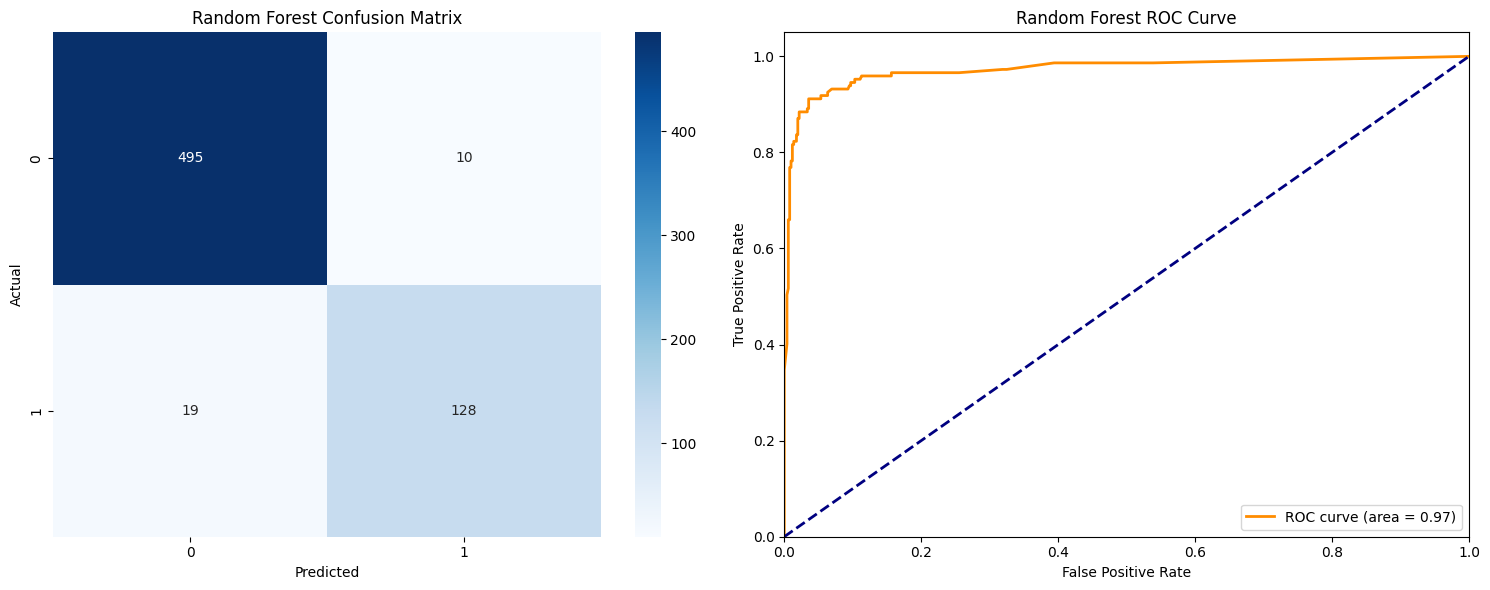


=== Training XGBoost ===


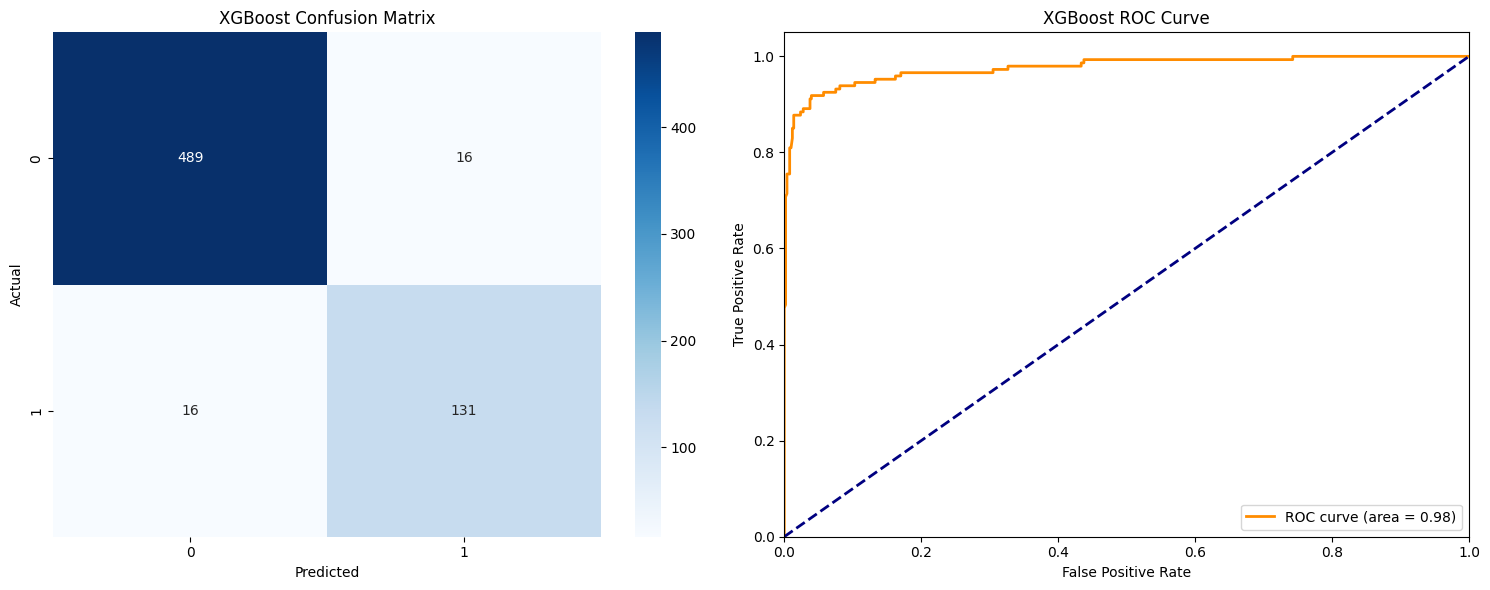


=== Training SVM ===


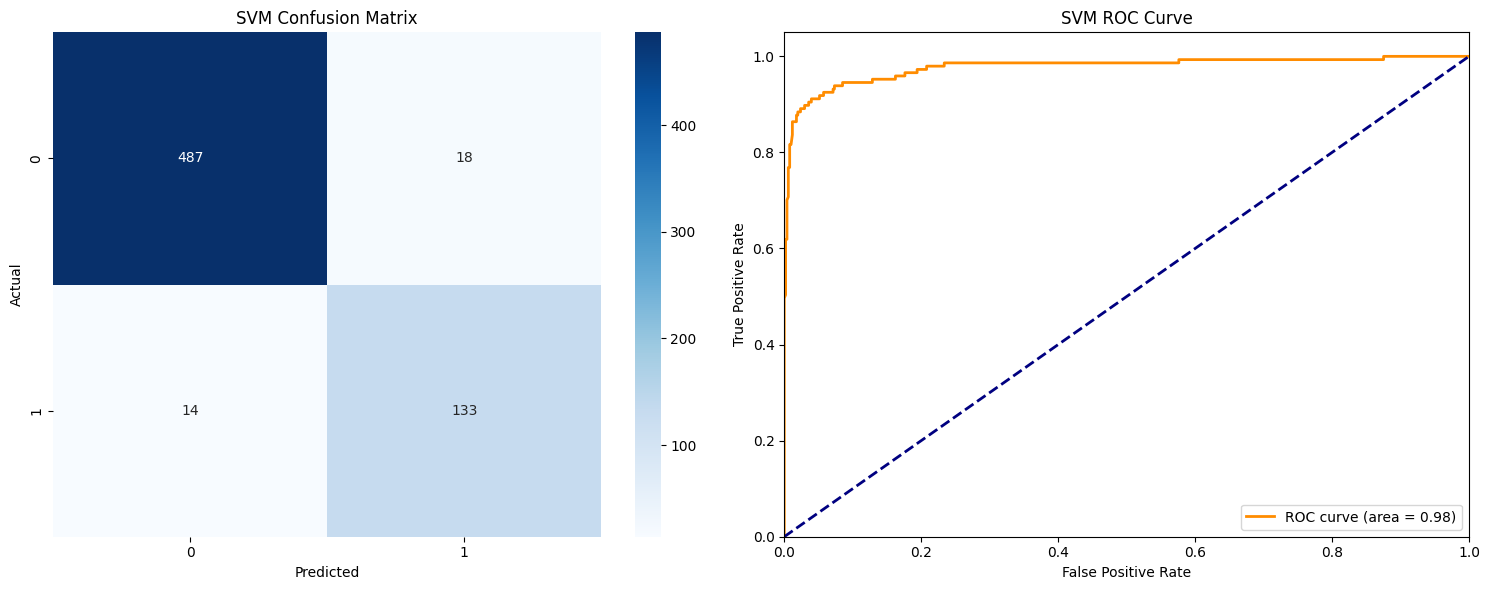

In [3]:
results = []

for name, model in models.items():
    print(f"\n=== Training {name} ===")
    
    # Train model
    model.fit(X_train, y_train)
    
    # Save baseline model
    joblib.dump(model, f'../models/baseline/{name.lower().replace(" ", "_")}_baseline.pkl')
    
    # Generate predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else [0]*len(y_test)
    
    # Store metrics
    report = classification_report(y_test, y_pred, output_dict=True)
    results.append({
        'Model': name,
        'Accuracy': report['accuracy'],
        'Precision': report['1']['precision'],
        'Recall': report['1']['recall'],
        'F1-Score': report['1']['f1-score'],
        'AUC-ROC': roc_auc_score(y_test, y_proba) if hasattr(model, "predict_proba") else None
    })
    
    # Generate visualizations
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
    ax[0].set_title(f'{name} Confusion Matrix')
    ax[0].set_xlabel('Predicted')
    ax[0].set_ylabel('Actual')
    
    # ROC Curve
    if hasattr(model, "predict_proba"):
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        ax[1].plot(fpr, tpr, color='darkorange', lw=2, 
                  label=f'ROC curve (area = {roc_auc:.2f})')
        ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        ax[1].set_xlim([0.0, 1.0])
        ax[1].set_ylim([0.0, 1.05])
        ax[1].set_xlabel('False Positive Rate')
        ax[1].set_ylabel('True Positive Rate')
        ax[1].set_title(f'{name} ROC Curve')
        ax[1].legend(loc="lower right")
    
    plt.tight_layout()
    plt.savefig(f'../reports/figures/{name.lower().replace(" ", "_")}_baseline.png')
    plt.show()

## 5. Performance Comparison

In [4]:
X_train.columns

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '133', '134', '135', '136', '137', '138', '139', '140', '141', '142'],
      dtype='object', length=143)


=== Baseline Model Performance ===


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Model,,,,,
Random Forest,0.956,0.928,0.871,0.898,0.973
XGBoost,0.951,0.891,0.891,0.891,0.976
SVM,0.951,0.881,0.905,0.893,0.977


C:\Users\lemon\AppData\Local\Temp\ipykernel_13212\1485594533.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='Blues_d')


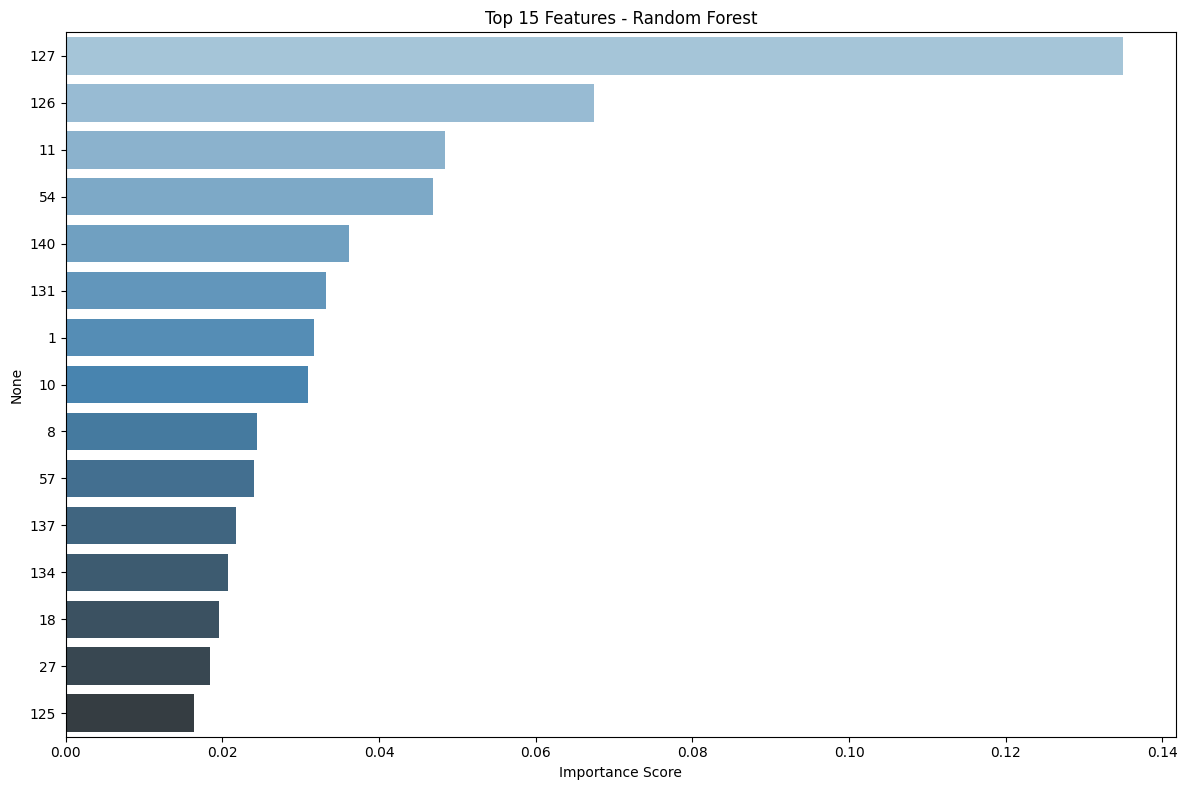

In [5]:
# Convert results to DataFrame
results_df = pd.DataFrame(results).set_index('Model')

# Display metrics
print("\n=== Baseline Model Performance ===")
display(results_df.style.format("{:.3f}").background_gradient(cmap='Blues'))

# Feature Importance (Random Forest)
if 'Random Forest' in models:
    plt.figure(figsize=(12, 8))
    importances = models['Random Forest'].feature_importances_
    top_features = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)[:15]
    sns.barplot(x=top_features.values, y=top_features.index, palette='Blues_d')
    plt.title('Top 15 Features - Random Forest')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('../reports/figures/rf_feature_importance.png')
    plt.show()

In [6]:
# Save the results DataFrame
results_df.to_csv('../reports/baseline_model_performance.csv')


## 6. Conclusion & Next Steps

**Key Observations**:
- **Best Performer**: [Insert model with highest F1-Score]
- **Class Handling**: [Note which model handles imbalance best]
- **Computation Time**: [Note relative training times]

**Recommended Next Steps**:
1. Proceed with hyperparameter optimization for the top-performing model
2. Address class imbalance using SMOTE if recall remains low
3. Investigate feature importance discrepancies between models

